<a href="https://colab.research.google.com/github/phoebegunawan/Phoebe_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining_PhoebeGunawan_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [3]:
from google.colab import files
files.upload()

Saving bread_basket-2.csv to bread_basket-2 (2).csv


{'bread_basket-2 (2).csv': b"transaction,item,date_time,time,period_day,weekday_weekend\r\n1,Bread,30/10/2016,9:58,morning,weekend\r\n2,Scandinavian,30/10/2016,10:05,morning,weekend\r\n2,Scandinavian,30/10/2016,10:05,morning,weekend\r\n3,Hot chocolate,30/10/2016,10:07,morning,weekend\r\n3,Jam,30/10/2016,10:07,morning,weekend\r\n3,Cookies,30/10/2016,10:07,morning,weekend\r\n4,Muffin,30/10/2016,10:08,morning,weekend\r\n5,Coffee,30/10/2016,10:13,morning,weekend\r\n5,Pastry,30/10/2016,10:13,morning,weekend\r\n5,Bread,30/10/2016,10:13,morning,weekend\r\n6,Medialuna,30/10/2016,10:16,morning,weekend\r\n6,Pastry,30/10/2016,10:16,morning,weekend\r\n6,Muffin,30/10/2016,10:16,morning,weekend\r\n7,Medialuna,30/10/2016,10:19,morning,weekend\r\n7,Pastry,30/10/2016,10:19,morning,weekend\r\n7,Coffee,30/10/2016,10:19,morning,weekend\r\n7,Tea,30/10/2016,10:19,morning,weekend\r\n8,Pastry,30/10/2016,10:20,morning,weekend\r\n8,Bread,30/10/2016,10:20,morning,weekend\r\n9,Bread,30/10/2016,10:21,morning,weeke

In [4]:
# write your answer here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# loading the data set
data_path = "bread_basket-2.csv"
df = pd.read_csv(data_path)

df.head()



,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [5]:
# Transaction: int64, item: object, date_time:object time: object
# period_day: object, weekday_weekend: object
#column name, non null count and d types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [6]:
# write your answer here
# take a screenshot DONT FORGET
df.describe(include="all")

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

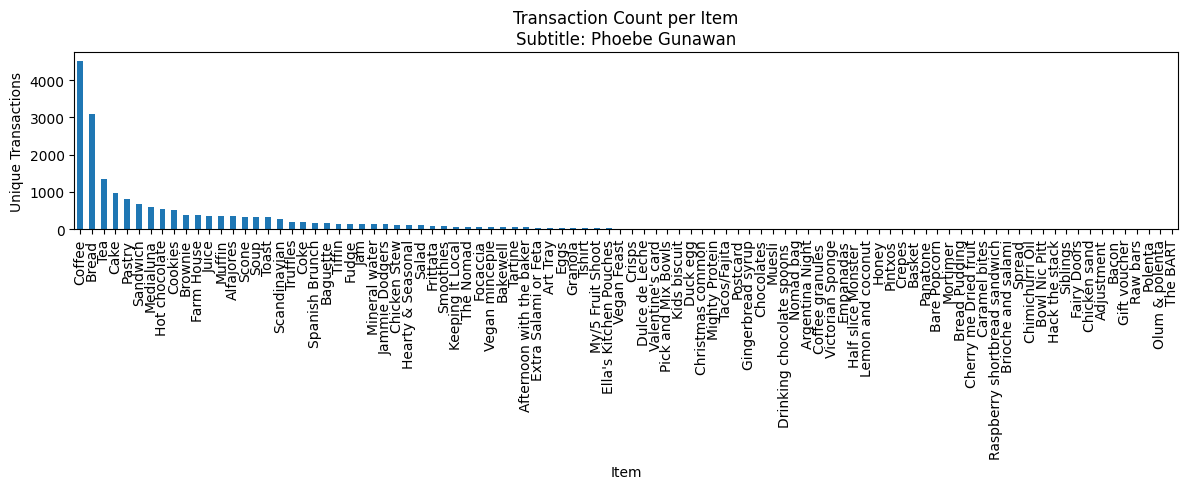

In [7]:
## TAKE S SCREENSHOT
# Subtitle
subtitle = "Phoebe Gunawan"

# transactions per the line
item_counts = (
    df.groupby("item")["transaction"]
      .nunique()
      .sort_values(ascending=False)
)

# Create bar chart
ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item")
plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

# this shows the unique transaction by every item highest ammount of
#unique transactions being coffee

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [8]:
# write your answer here

# the counts of cofee, tea, alfajores,juice and chciken stew
target_items = ["Coffee","Tea","Alfajores","Juice","Chicken Stew"]

# determine the items counts
item_counts = (
    df.groupby("item")["transaction"]
    .nunique()
)

report_counts = item_counts.reindex(target_items)

#dipslay
report_counts

# Coffee: 4528, Tea : 1350, Alfrajores:344, Juice: 365, Chicken stew: 123

,transaction
item,
Coffee,4528
Tea,1350
Alfajores,344
Juice,365
Chicken Stew,123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [9]:

from mlxtend.frequent_patterns import fpgrowth
#one hot transaction
oht = pd.crosstab(df['transaction'], df['item']).astype(bool)
print("One-hot table shape:", oht.shape)
display(oht.head())

freq_itemsets_020 = fpgrowth(oht, min_support=0.20, use_colnames=True)
print("Frequent itemsets with min_support=0.20:", len(freq_itemsets_020))
display(freq_itemsets_020.sort_values('support', ascending=False))

#the assocication rule
freq_itemsets = fpgrowth(oht, min_support=0.01, use_colnames=True)
print("Frequent itemsets with min_support=0.01:", len(freq_itemsets))
display(freq_itemsets.sort_values('support', ascending=False).head(20))

One-hot table shape: (9465, 94)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
transaction,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Frequent itemsets with min_support=0.20: 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Frequent itemsets with min_support=0.01: 61


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
6,0.478394,(Coffee)
0,0.327205,(Bread)
9,0.142631,(Tea)
16,0.103856,(Cake)
30,0.090016,"(Bread, Coffee)"
7,0.086107,(Pastry)
18,0.071844,(Sandwich)
8,0.061807,(Medialuna)
2,0.058320,(Hot chocolate)
46,0.054728,"(Coffee, Cake)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [10]:
from mlxtend.frequent_patterns import association_rules
#threshold rule
min_threshold = 0.15

rules = association_rules(freq_itemsets, metric="confidence", min_threshold=min_threshold)

print("Min confidence threshold:", min_threshold)
print("Number of rules:", len(rules))

#making the table
report_cols = ["antecedents", "consequents", "support", "confidence", "lift"]
report = (rules[report_cols]
          .sort_values(["confidence", "lift"], ascending=False)
          .reset_index(drop=True))

display(report.head(20))

#the rules
target_rule = report[
    (report["antecedents"] == frozenset(["Coffee", "Cake"])) &
    (report["consequents"] == frozenset(["Bread"]))
]
print("Target rule {Coffee, Cake}->{Bread}:")
display(target_rule)

# the association rule generates rules that show the relationship[ between
# the pruchse items.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Min confidence threshold: 0.15
Number of rules: 37


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
0,(Toast),(Coffee),0.023666,0.704403,1.472431
1,(Spanish Brunch),(Coffee),0.010882,0.598837,1.251766
2,(Medialuna),(Coffee),0.035182,0.569231,1.189878
3,(Pastry),(Coffee),0.047544,0.552147,1.154168
4,(Alfajores),(Coffee),0.019651,0.540698,1.130235
5,(Juice),(Coffee),0.020602,0.534247,1.116750
6,(Sandwich),(Coffee),0.038246,0.532353,1.112792
7,(Cake),(Coffee),0.054728,0.526958,1.101515
8,(Scone),(Coffee),0.018067,0.522936,1.093107
9,(Cookies),(Coffee),0.028209,0.518447,1.083723


Target rule {Coffee, Cake}->{Bread}:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
35,"(Coffee, Cake)",(Bread),0.010037,0.183398,0.560497


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (
  support: the fraction that contains coffee,cake and bread rother is 1% the support is 0.010037 which is 1%

  confidence: the ammount that share also include bread is 18.3% because the confidence is 0.183398

  Lift >1:
  the life is less than one which mean is is a negative association because the lift is 0.560497. The practical meaning is if someone buys coffee and cake it does not increase the likelihood of buying bread.
)